# Global Sensitivity C-revised — weighted class Strategy-specific Tuning

C-old는 사용하지 않는다. 이 Notebook은 Global Train의 25개 Feature, SAMPID-level `sample_weight`, fold별 weighted class correction을 고정 구성으로 유지한 제한 GridSearch와 Train OOF를 실행한다. Test·Feature Selection·threshold tuning은 사용하지 않는다.


## 1. 입력·Feature 계약·예상 학습량


In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

ROOT = Path(os.environ.get("KHUDA_PROJECT_ROOT", Path.cwd())).resolve()
while not (ROOT / "code").is_dir():
    if ROOT.parent == ROOT:
        raise RuntimeError("저장소 안에서 Notebook을 실행하거나 KHUDA_PROJECT_ROOT를 지정하세요.")
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if "code" in sys.modules and not hasattr(sys.modules["code"], "__path__"):
    del sys.modules["code"]

from code.evaluation.evaluate import calculate_binary_metrics
from code.model.locked_sensitivity import load_stage_3_5_locked_params
from code.model.strategy_tuning import (
    count_grid_combinations,
    run_b_lr_tuning,
    run_c_lr_tuning,
    run_xgb_tuning_stage_a,
    run_xgb_tuning_stage_b,
    run_xgb_tuning_stage_c,
    save_strategy_tuning_artifacts,
    step3_tuning_grids,
)
from code.pipeline.audit import (
    attach_person_period_column,
    calculate_train_sample_weight,
    load_selected_feature_names,
)
from code.pipeline.saved_results import load_saved_global_train, select_bundle_features

RESULT_ROOT = ROOT / "data" / "result" / "baseline_42features"
DATASET_PATH = RESULT_ROOT / "datasets" / "global_dataset.parquet"
SPLIT_PATH = RESULT_ROOT / "splits" / "split_ids.csv"
FEATURE_CONFIG = ROOT / "code" / "config" / "features.yaml"
MODEL_CONFIG = ROOT / "code" / "config" / "model_config.yaml"
STAGE35 = RESULT_ROOT / "modeling" / "stage_3_5"
SELECTED = RESULT_ROOT / "modeling" / "stage_3" / "selected_features.csv"
PARAMS = STAGE35 / "final_refined_params.json"
A_SUMMARY = STAGE35 / "final_tuning_summary.csv"
A_FOLD = STAGE35 / "final_fold_f1.json"
A_OOF = {model: STAGE35 / f"refined_{model}_oof_predictions.parquet" for model in ("logistic_regression", "xgboost")}
# Jupyter worker의 표준 라이브러리 code 이름 충돌을 피한다. GridSearch 병렬 수는 n_jobs=-1을 유지한다.
PARALLEL_BACKEND = "threading"
COLORS = {"A Baseline":"#7a7a7a", "Locked":"#0066cc", "Tuned":"#2997ff"}

LOCKED_DIR = RESULT_ROOT / "modeling" / "sensitivity_sample_weight_weighted_class"
OUT = LOCKED_DIR / "tuning"
LOCKED_SUMMARY = LOCKED_DIR / "locked_model_summary.csv"
LOCKED_FOLD = LOCKED_DIR / "locked_fold_f1.json"
LOCKED_OOF = {model: LOCKED_DIR / f"locked_{model}_oof_predictions.parquet" for model in ("logistic_regression", "xgboost")}


In [2]:
required = [DATASET_PATH, SPLIT_PATH, FEATURE_CONFIG, MODEL_CONFIG, SELECTED, PARAMS, A_SUMMARY, A_FOLD, LOCKED_SUMMARY, LOCKED_FOLD, *A_OOF.values(), *LOCKED_OOF.values()]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("필요한 저장 산출물이 없습니다:\n" + "\n".join(missing))
base = load_saved_global_train(DATASET_PATH, SPLIT_PATH, FEATURE_CONFIG)
selected = load_selected_feature_names(SELECTED)
TRAIN = select_bundle_features(base, selected, name="global_step3_c")
weights = calculate_train_sample_weight(TRAIN.groups)
params = load_stage_3_5_locked_params(PARAMS)
grids = step3_tuning_grids(MODEL_CONFIG, strategy="C")
assert TRAIN.X.shape[1] == 25
assert "n_prior_periods" not in TRAIN.X.columns
assert weights.groupby(TRAIN.groups).sum().sub(1).abs().le(1e-12).all()
display(pd.DataFrame([{
    "strategy": "C revised tuned", "train_rows": len(TRAIN.y), "unique_SAMPID": TRAIN.groups.nunique(),
    "feature_count": TRAIN.X.shape[1], "sample_weight_used_for_fit": True, "test_used": False,
    "lr_combinations": count_grid_combinations(grids["logistic_regression"]), "lr_expected_fits": 70,
    "xgb_expected_fits": 585, "core_cv_fits": 655,
}]))


,strategy,train_rows,unique_SAMPID,feature_count,sample_weight_used_for_fit,test_used,lr_combinations,lr_expected_fits,xgb_expected_fits,core_cv_fits
0,C revised tuned,11925,5737,25,True,False,14,70,585,655


## 2. 제한 GridSearch — C-revised tuned

LR은 `class_weight`를 탐색하지 않는다. XGBoost도 raw row ratio가 아니라 fold별 weighted mass ratio를 사용한다.


In [3]:
lr_tuned = run_c_lr_tuning(TRAIN, sample_weight_train=weights, feature_config=FEATURE_CONFIG, model_config=MODEL_CONFIG, parallel_backend_name=PARALLEL_BACKEND, n_jobs=-1)
xgb_a = run_xgb_tuning_stage_a(TRAIN, strategy="C", stage35_params=params["xgboost"], sample_weight_train=weights, feature_config=FEATURE_CONFIG, model_config=MODEL_CONFIG, parallel_backend_name=PARALLEL_BACKEND, n_jobs=-1)
xgb_b = run_xgb_tuning_stage_b(TRAIN, strategy="C", stage_a_params=xgb_a.best_params, sample_weight_train=weights, feature_config=FEATURE_CONFIG, model_config=MODEL_CONFIG, parallel_backend_name=PARALLEL_BACKEND, n_jobs=-1)
xgb_tuned = run_xgb_tuning_stage_c(TRAIN, strategy="C", stage_b_params=xgb_b.best_params, sample_weight_train=weights, feature_config=FEATURE_CONFIG, model_config=MODEL_CONFIG, parallel_backend_name=PARALLEL_BACKEND, n_jobs=-1)
tuned_results = [lr_tuned, xgb_tuned]
fold_results = pd.concat([
    pd.DataFrame({"fold": range(5), "strategy": item.strategy, "model": item.search.model, "f1": item.search.fold_f1})
    for item in tuned_results
], ignore_index=True)
weighted_class_audit = pd.concat([item.audit.assign(strategy=item.strategy, model=item.search.model) for item in tuned_results], ignore_index=True)
display(pd.DataFrame([item.summary_row() for item in tuned_results]))
display(fold_results)
display(weighted_class_audit)


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebre

,strategy,model,feature_count,best_cv_f1,cv_f1_mean,cv_f1_std,oof_accuracy,oof_precision,oof_recall,oof_f1,oof_roc_auc,oof_average_precision,predicted_positive_rate,best_params
0,C revised tuned,logistic_regression,None,0.483073,0.483073,0.021540,0.686289,0.424169,0.560976,0.483073,0.691567,0.425611,0.345577,"{'class_weight': 'weighted_class_balanced', 'C..."
1,C revised tuned,xgboost,None,0.496699,0.496699,0.020988,0.667505,0.410875,0.628049,0.496764,0.704397,0.434656,0.399413,{'scale_pos_weight': 'train_weighted_negative_...


,fold,strategy,model,f1
0,0,C revised tuned,logistic_regression,0.464924
1,1,C revised tuned,logistic_regression,0.515193
2,2,C revised tuned,logistic_regression,0.454864
3,3,C revised tuned,logistic_regression,0.495739
4,4,C revised tuned,logistic_regression,0.484646
5,0,C revised tuned,xgboost,0.479695
6,1,C revised tuned,xgboost,0.529081
7,2,C revised tuned,xgboost,0.469466
8,3,C revised tuned,xgboost,0.507772
9,4,C revised tuned,xgboost,0.497481


,fold,raw_pos,raw_neg,W_pos,W_neg,raw_neg_pos_ratio,weighted_neg_pos_ratio,class_weight_0,class_weight_1,strategy,model,scale_pos_weight
0,0,2493,7048,1697.833333,2911.166667,2.827116,1.714636,0.791607,1.357318,C revised tuned,logistic_regression,NaN
1,1,2493,7048,1688.000000,2894.000000,2.827116,1.714455,0.791638,1.357227,C revised tuned,logistic_regression,NaN
2,2,2493,7046,1688.666667,2892.333333,2.826314,1.712791,0.791921,1.356396,C revised tuned,logistic_regression,NaN
3,3,2493,7046,1690.000000,2896.000000,2.826314,1.713609,0.791782,1.356805,C revised tuned,logistic_regression,NaN
4,4,2492,7048,1690.166667,2899.833333,2.828250,1.715709,0.791425,1.357854,C revised tuned,logistic_regression,NaN
5,0,2493,7048,1697.833333,2911.166667,2.827116,1.714636,NaN,NaN,C revised tuned,xgboost,1.714636
6,1,2493,7048,1688.000000,2894.000000,2.827116,1.714455,NaN,NaN,C revised tuned,xgboost,1.714455
7,2,2493,7046,1688.666667,2892.333333,2.826314,1.712791,NaN,NaN,C revised tuned,xgboost,1.712791
8,3,2493,7046,1690.000000,2896.000000,2.826314,1.713609,NaN,NaN,C revised tuned,xgboost,1.713609
9,4,2492,7048,1690.166667,2899.833333,2.828250,1.715709,NaN,NaN,C revised tuned,xgboost,1.715709


## 3. C-revised tuned 전용 저장


In [4]:
artifact_paths = save_strategy_tuning_artifacts(output_dir=OUT, bundle=TRAIN, tuned_results=tuned_results, lr_search=lr_tuned.search, xgb_stage_a=xgb_a, xgb_stage_b=xgb_b, xgb_stage_c=xgb_tuned.search)
display(pd.DataFrame({"artifact": artifact_paths.keys(), "path": [str(path) for path in artifact_paths.values()]}))


,artifact,path
0,summary,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
1,best_params,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
2,fold_f1,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
3,logistic_regression_search_results,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
4,xgboost_refinement_stage_a,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
5,xgboost_refinement_stage_b,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
6,xgboost_refinement_stage_c,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
7,logistic_regression_oof,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
8,xgboost_oof,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
9,confusion_matrices,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...


## 4. A · C-revised locked · C-revised tuned 비교

자동 해석이나 Strategy 선택은 생성하지 않는다.


In [5]:
def normalize_oof(frame):
    return frame.rename(columns={
        "y_proba": "y_probability",
        "y_pred": "y_predicted",
        "y_pred_at_0_5": "y_predicted",
    })

def rows_from_saved(strategy, summary_path, oof_paths, *, stage=None, parameter_status="locked"):
    summary = pd.read_csv(summary_path)
    if stage is not None:
        summary = summary.loc[summary["stage"].eq(stage)].copy()
    summary = summary.set_index("model")
    if not summary.index.is_unique:
        raise ValueError(f"{strategy} summary에는 모델별 한 행만 있어야 합니다.")
    rows, oofs = [], {}
    for model, path in oof_paths.items():
        oof = normalize_oof(pd.read_parquet(path))
        metric = calculate_binary_metrics(oof["y_true"], oof["y_probability"])
        oofs[model] = oof
        rows.append({
            "strategy": strategy,
            "model": model,
            "feature_count": int(summary.loc[model, "feature_count"]),
            "parameter_status": parameter_status,
            "cv_f1_mean": summary.loc[model, "cv_f1_mean"],
            "cv_f1_std": summary.loc[model, "cv_f1_std"],
            "oof_precision": metric["precision"],
            "oof_recall": metric["recall"],
            "oof_f1": metric["f1"],
            "oof_roc_auc": metric["roc_auc"],
            "oof_average_precision": metric["average_precision"],
            "predicted_positive_rate": oof["y_predicted"].mean(),
            "best_params": summary.loc[model, "best_params"] if "best_params" in summary else None,
        })
    return pd.DataFrame(rows), oofs

def tuned_rows(results):
    rows, oofs = [], {}
    for result in results:
        row = result.summary_row()
        row["feature_count"] = TRAIN.X.shape[1]
        row["parameter_status"] = "tuned"
        rows.append(row)
        oofs[result.search.model] = result.oof_predictions
    return pd.DataFrame(rows), oofs

def add_f1_deltas(comparison, locked_label, tuned_label):
    baseline = comparison.query("strategy == 'A Baseline'").set_index("model")["oof_f1"]
    locked = comparison.query("strategy == @locked_label").set_index("model")["oof_f1"]
    result = comparison.copy()
    result[f"{locked_label}_minus_A_oof_f1"] = result.apply(lambda row: row.oof_f1 - baseline[row.model], axis=1)
    result[f"{tuned_label}_minus_A_oof_f1"] = result.apply(lambda row: row.oof_f1 - baseline[row.model], axis=1)
    result[f"{tuned_label}_minus_{locked_label}_oof_f1"] = result.apply(lambda row: row.oof_f1 - locked[row.model], axis=1)
    return result

a_rows, _ = rows_from_saved("A Baseline", A_SUMMARY, A_OOF, stage="stage_3_5")
locked_rows, locked_oof = rows_from_saved("C revised locked", LOCKED_SUMMARY, LOCKED_OOF)
locked_rows["best_params"] = locked_rows["model"].map(params)
tuned_rows_frame, tuned_oof = tuned_rows(tuned_results)
comparison = pd.concat([a_rows, locked_rows, tuned_rows_frame], ignore_index=True)
comparison = add_f1_deltas(comparison, "C revised locked", "C revised tuned")
display(comparison)
with LOCKED_FOLD.open(encoding="utf-8") as file:
    locked_fold = json.load(file)


,strategy,model,feature_count,parameter_status,cv_f1_mean,cv_f1_std,oof_precision,oof_recall,oof_f1,oof_roc_auc,oof_average_precision,predicted_positive_rate,best_params,best_cv_f1,oof_accuracy,C revised locked_minus_A_oof_f1,C revised tuned_minus_A_oof_f1,C revised tuned_minus_C revised locked_oof_f1
0,A Baseline,logistic_regression,25,locked,0.493122,0.022909,0.421846,0.592426,0.492792,0.702235,0.430911,0.366960,"{'C': 0.3, 'class_weight': 'balanced', 'penalt...",NaN,NaN,0.000000,0.000000,0.010891
1,A Baseline,xgboost,25,locked,0.507894,0.016047,0.413689,0.657574,0.507870,0.710534,0.441191,0.415346,"{'subsample': 1.0, 'colsample_bytree': 0.8, 's...",NaN,NaN,0.000000,0.000000,0.013734
2,C revised locked,logistic_regression,25,locked,0.481941,0.020577,0.423096,0.559692,0.481901,0.691217,0.424212,0.345660,"{'C': 0.3, 'class_weight': 'balanced', 'penalt...",NaN,NaN,-0.010891,-0.010891,0.000000
3,C revised locked,xgboost,25,locked,0.494076,0.023327,0.409898,0.621951,0.494136,0.702235,0.430521,0.396478,"{'subsample': 1.0, 'colsample_bytree': 0.8, 's...",NaN,NaN,-0.013734,-0.013734,0.000000
4,C revised tuned,logistic_regression,25,tuned,0.483073,0.021540,0.424169,0.560976,0.483073,0.691567,0.425611,0.345577,"{'class_weight': 'weighted_class_balanced', 'C...",0.483073,0.686289,-0.009719,-0.009719,0.001172
5,C revised tuned,xgboost,25,tuned,0.496699,0.020988,0.410875,0.628049,0.496764,0.704397,0.434656,0.399413,{'scale_pos_weight': 'train_weighted_negative_...,0.496699,0.667505,-0.011106,-0.011106,0.002628


## 5. 비교 그래프와 fold별 weighted class ratio


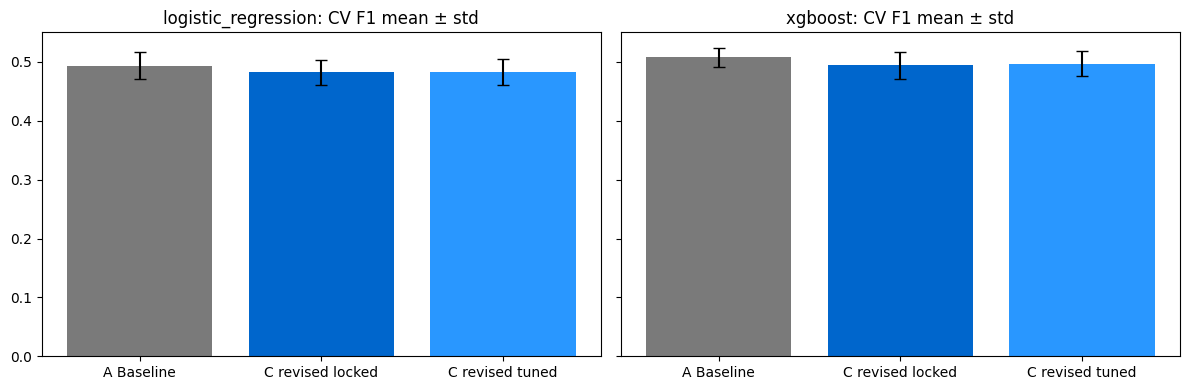

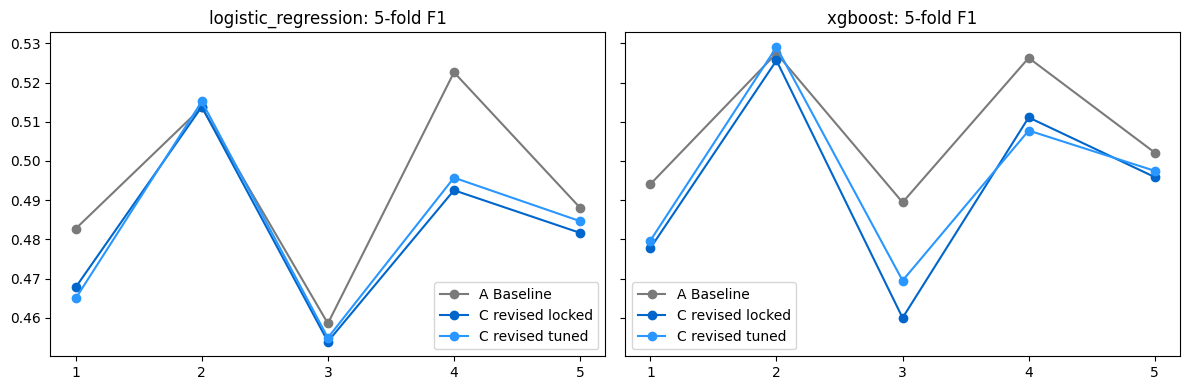

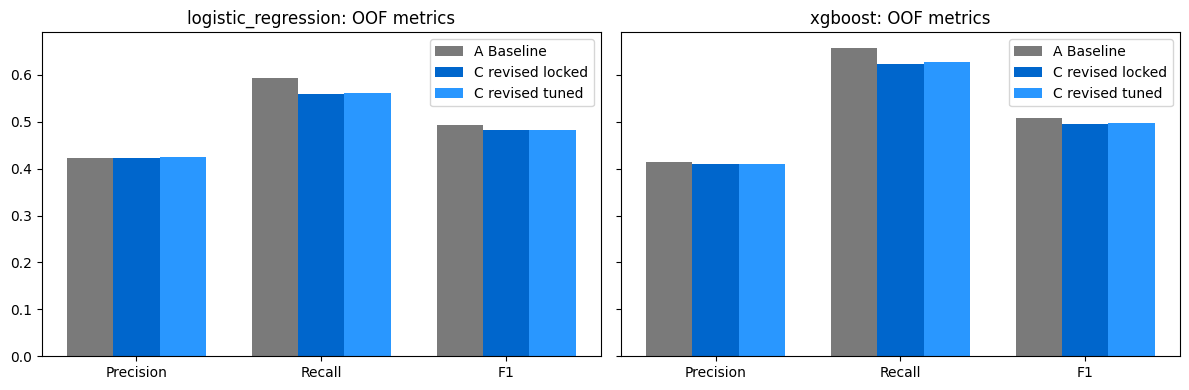

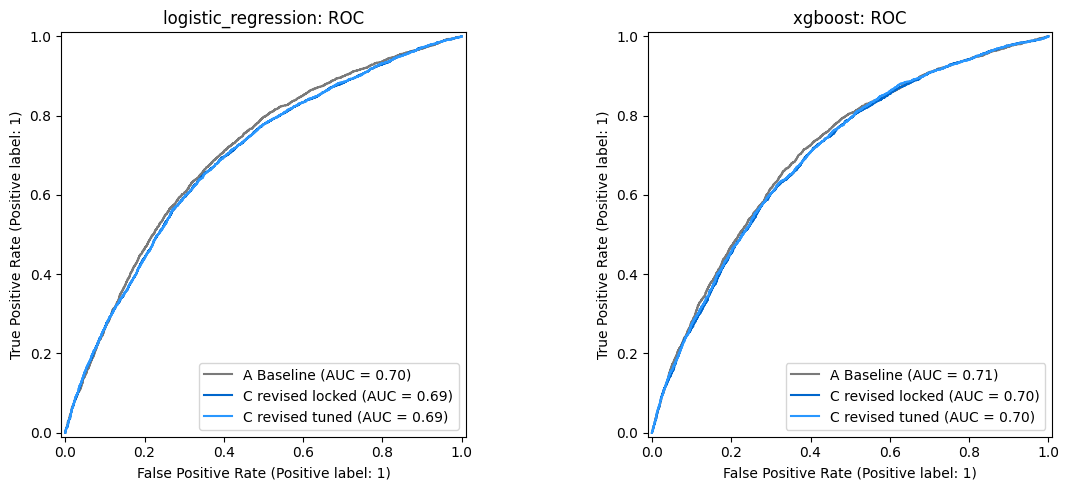

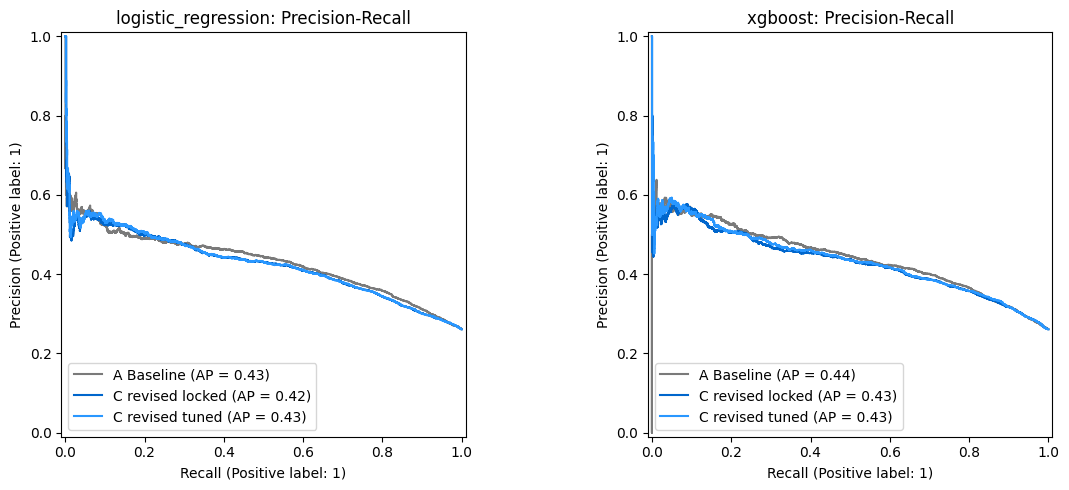

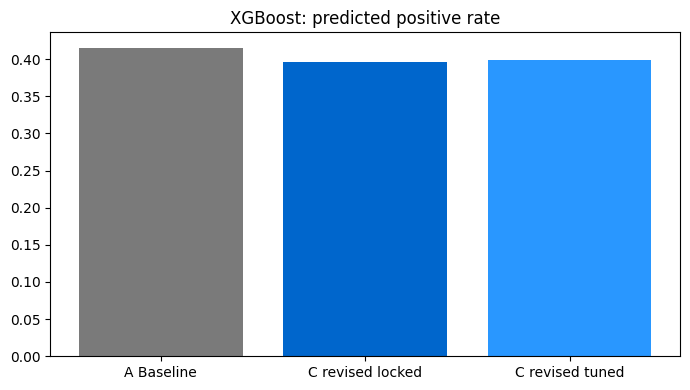

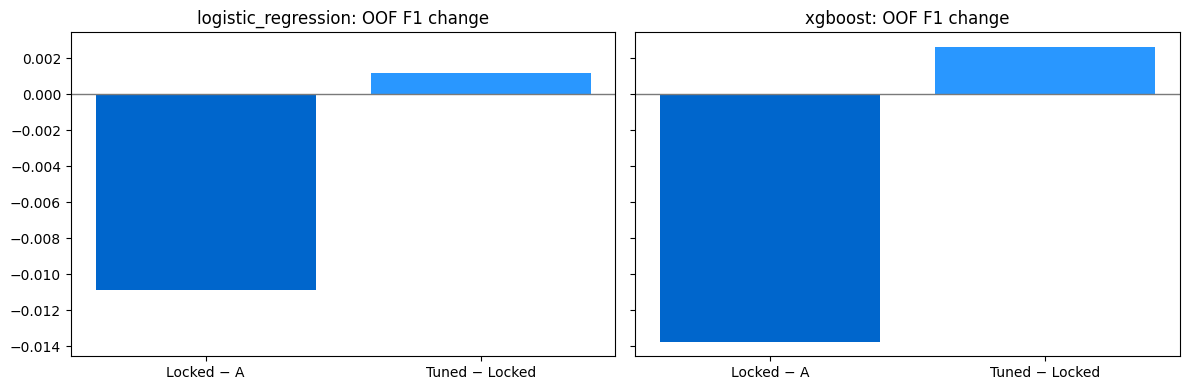

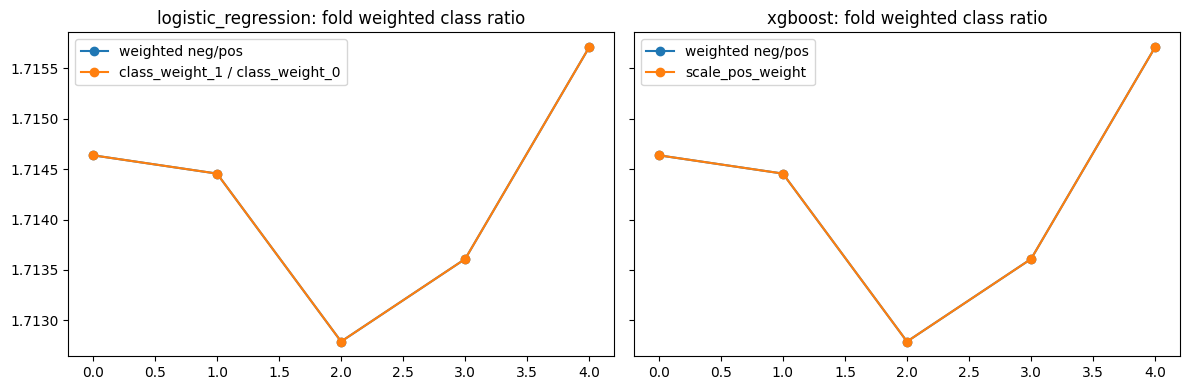

In [6]:
def plot_comparison(comparison, saved_oof, tuned_oof, saved_fold, tuned_results, *, locked_label, tuned_label, include_ppr):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, model in zip(axes, ("logistic_regression", "xgboost")):
        rows = comparison.query("model == @model")
        colors = [COLORS["A Baseline"], COLORS["Locked"], COLORS["Tuned"]]
        ax.bar(rows.strategy, rows.cv_f1_mean, yerr=rows.cv_f1_std, color=colors, capsize=4)
        ax.set_title(f"{model}: CV F1 mean ± std")
    plt.tight_layout(); plt.show()

    with A_FOLD.open(encoding="utf-8") as file:
        baseline_fold = json.load(file)["stage_3_5"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, model in zip(axes, ("logistic_regression", "xgboost")):
        ax.plot(range(1, 6), baseline_fold[model], marker="o", label="A Baseline", color=COLORS["A Baseline"])
        ax.plot(range(1, 6), saved_fold[model], marker="o", label=locked_label, color=COLORS["Locked"])
        ax.plot(range(1, 6), next(item.search.fold_f1 for item in tuned_results if item.search.model == model), marker="o", label=tuned_label, color=COLORS["Tuned"])
        ax.set_title(f"{model}: 5-fold F1"); ax.set_xticks(range(1, 6)); ax.legend()
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    metrics = ["oof_precision", "oof_recall", "oof_f1"]
    for ax, model in zip(axes, ("logistic_regression", "xgboost")):
        rows = comparison.query("model == @model").set_index("strategy").loc[["A Baseline", locked_label, tuned_label]]
        positions = np.arange(len(metrics)); width = 0.25
        for offset, (label, row, color) in enumerate(zip(rows.index, rows.itertuples(), [COLORS["A Baseline"], COLORS["Locked"], COLORS["Tuned"]])):
            ax.bar(positions + (offset - 1) * width, [getattr(row, metric) for metric in metrics], width, label=label, color=color)
        ax.set_xticks(positions, ["Precision", "Recall", "F1"]); ax.set_title(f"{model}: OOF metrics"); ax.legend()
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, model in zip(axes, ("logistic_regression", "xgboost")):
        for label, collection, color in [("A Baseline", A_OOF, COLORS["A Baseline"]), (locked_label, saved_oof, COLORS["Locked"]), (tuned_label, tuned_oof, COLORS["Tuned"])]:
            value = collection[model]
            oof = normalize_oof(pd.read_parquet(value)) if isinstance(value, (str, Path)) else value
            RocCurveDisplay.from_predictions(oof["y_true"], oof["y_probability"], name=label, ax=ax, curve_kwargs={"color": color})
        ax.set_title(f"{model}: ROC")
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, model in zip(axes, ("logistic_regression", "xgboost")):
        for label, collection, color in [("A Baseline", A_OOF, COLORS["A Baseline"]), (locked_label, saved_oof, COLORS["Locked"]), (tuned_label, tuned_oof, COLORS["Tuned"])]:
            value = collection[model]
            oof = normalize_oof(pd.read_parquet(value)) if isinstance(value, (str, Path)) else value
            PrecisionRecallDisplay.from_predictions(oof["y_true"], oof["y_probability"], name=label, ax=ax, curve_kwargs={"color": color})
        ax.set_title(f"{model}: Precision-Recall")
    plt.tight_layout(); plt.show()

    if include_ppr:
        fig, ax = plt.subplots(figsize=(7, 4))
        rows = comparison.query("model == 'xgboost'")
        ax.bar(rows.strategy, rows.predicted_positive_rate, color=[COLORS["A Baseline"], COLORS["Locked"], COLORS["Tuned"]])
        ax.set_title("XGBoost: predicted positive rate")
        plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, model in zip(axes, ("logistic_regression", "xgboost")):
        rows = comparison.query("model == @model").set_index("strategy")
        ax.bar(["Locked − A", "Tuned − Locked"], [rows.loc[locked_label, "oof_f1"] - rows.loc["A Baseline", "oof_f1"], rows.loc[tuned_label, "oof_f1"] - rows.loc[locked_label, "oof_f1"]], color=[COLORS["Locked"], COLORS["Tuned"]])
        ax.axhline(0, color="#7a7a7a", linewidth=1); ax.set_title(f"{model}: OOF F1 change")
    plt.tight_layout(); plt.show()

plot_comparison(comparison, locked_oof, tuned_oof, locked_fold, tuned_results, locked_label="C revised locked", tuned_label="C revised tuned", include_ppr=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, model in zip(axes, ("logistic_regression", "xgboost")):
    audit = weighted_class_audit.query("model == @model")
    ax.plot(audit.fold, audit.weighted_neg_pos_ratio, marker="o", label="weighted neg/pos")
    if model == "logistic_regression":
        ax.plot(audit.fold, audit.class_weight_1 / audit.class_weight_0, marker="o", label="class_weight_1 / class_weight_0")
    else:
        ax.plot(audit.fold, audit.scale_pos_weight, marker="o", label="scale_pos_weight")
    ax.set_title(f"{model}: fold weighted class ratio"); ax.legend()
plt.tight_layout(); plt.show()
